# [기초-실습] 통계 101×데이터 분석: (7장) 싱관과 회귀

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비

### 1단계 · 한글 폰트 설치

- 그래프에 한글이 깨지지 않도록 나눔 폰트를 설치합니다.

- 실행 후 **[런타임] - [세션 다시 시작]**을 한 번 눌러야 폰트가 적용됩니다.

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels


### 2단계 · 라이브러리 불러오기

- 이번 실습에서 쓰는 도구입니다. **한 번만 실행**해 두면 끝까지 사용합니다.

- `smf`는 회귀식을 `'y ~ x'` 형태로 쓰는 모듈, `het_breuschpagan`은 등분산 검정 함수입니다.

In [6]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

import matplotlib.font_manager as fm

font_path = '/System/Library/AssetsV2/com_apple_MobileAsset_Font7/bad9b4bf17cf1669dde54184ba4431c22dcad27b.asset/AssetData/NanumGothic.ttc'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()  # 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False


## 문제 1 · 펭귄의 부리는 길수록 두꺼울까?

`난이도 하` · `예상 15분`

**📖 상황**

- 남극 팔머 기지에서 측정한 펭귄 344마리의 신체 데이터(`penguins`)를 사용합니다.

- 부리 길이(`bill_length_mm`)와 부리 두께(`bill_depth_mm`)가 함께 어떻게 움직이는지 봅니다.

- 그런데 이 데이터에는 **세 종(Adelie·Chinstrap·Gentoo)이 섞여 있습니다.**
  전체를 뭉쳐서 볼 때와 집단을 나눠서 볼 때 **결론이 정반대로 뒤집히는 일**이 실제로 일어납니다.

**🎯 이 문제로 배우는 것**

- 상관계수를 계산하기 **전에** 산점도를 먼저 그려야 하는 이유를, 숫자로 직접 확인합니다.

In [4]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Q1 · 산점도로 두 변수의 관계를 그려 봅시다

- 가로축 `bill_length_mm`, 세로축 `bill_depth_mm`로 산점도를 그리세요.

- 그래프 제목과 축 라벨을 한글로 알아보기 쉽게 설정하세요.

- `💡 힌트` `sns.scatterplot(data=..., x=..., y=...)` / `plt.title()`, `plt.xlabel()`, `plt.ylabel()`

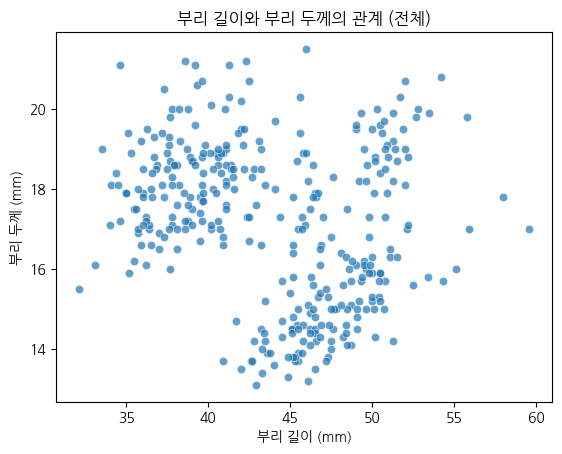

In [7]:
# 문제 1 · Q1
# 여기에 코드를 작성해주세요.
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', alpha=0.7)
plt.title('부리 길이와 부리 두께의 관계 (전체)')
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 두께 (mm)')
plt.show()


### Q2 · 종별로 색을 나눠 같은 그림을 다시 그려 봅시다

- Q1과 똑같은 산점도에 펭귄의 종(`species`)별로 점의 색을 다르게 칠하세요.

- Q1의 그림과 나란히 놓고 무엇이 달라 보이는지 관찰하세요.

- `💡 힌트` `sns.scatterplot()`에 `hue` 인수를 추가해 보세요.

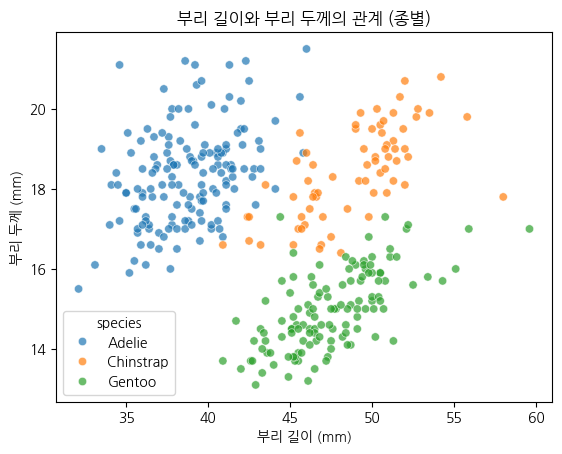

In [8]:
# 문제 1 · Q2
# 여기에 코드를 작성해주세요.
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species', alpha=0.7)
plt.title('부리 길이와 부리 두께의 관계 (종별)')
plt.xlabel('부리 길이 (mm)')
plt.ylabel('부리 두께 (mm)')
plt.show()


### Q3 · 상관계수를 '전체'와 '종별'로 각각 구해 비교해 봅시다

- 두 변수의 상관계수를 **전체 데이터**에 대해 계산하세요.

- 같은 상관계수를 **종별로 나누어** 계산하세요.

- 두 결과의 **부호**를 비교하세요.

- `💡 힌트` 전체는 `df[['A','B']].dropna().corr()`,
  종별은 `df.groupby('species')[['A','B']].corr()`를 활용해 보세요.

In [9]:
# 문제 1 · Q3
# 여기에 코드를 작성해주세요.
# 전체 상관계수
overall_corr = penguins[['bill_length_mm', 'bill_depth_mm']].dropna().corr()
print("전체 상관계수:\n", overall_corr)

# 종별 상관계수
species_corr = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()
print("\n종별 상관계수:\n", species_corr)


전체 상관계수:
                 bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.235053
bill_depth_mm        -0.235053       1.000000

종별 상관계수:
                           bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.391492
          bill_depth_mm         0.391492       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.643384
          bill_depth_mm         0.643384       1.000000


### 💬 정리 · 결과를 말로 설명해 보기

- Q1의 산점도에서 두 변수는 어떤 방향의 관계로 보였나요? Q3의 전체 상관계수와 부호가 일치하나요?

- Q3의 종별 상관계수는 전체와 부호가 같나요, 다른가요?

- **같은 데이터인데 전체와 집단별 결론이 정반대로 나온 이유**를 설명해 보세요. 무엇이 이 착시를 만들고 있나요?

- 만약 이 데이터에 '종' 정보가 없었다면 우리는 어떤 잘못된 결론을 내렸을까요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 부호가 뒤집히는 열쇠는 **종마다 부리의 '기본 크기'가 다르다**는 데 있습니다. 종별 평균이 어디에 놓여 있는지를 Q2의 그림에서 확인해 보세요.

- "전체를 보면 음, 나누면 양"은 두 변수 사이에 **숨은 집단 변수**가 끼어 있을 때 나타납니다. 이 현상에는 이름이 붙어 있고, 다음 시간 인과추론에서 다시 만납니다.

- 결론의 형태를 이렇게 나눠 써 보면 정확해집니다 — "종을 무시하면 ○○, 종을 고려하면 ○○".

</details>

### 문제 1 · 정리
#### 여기에 의견을 작성해주세요.

- Q1의 산점도에서 두 변수는 부리 길이가 길어질수록 부리 두께가 얕아지는 오른쪽 아래로 향하는 음의 방향처럼 보인다. Q3에서 계산한 전체 상관계수도 음수였기에 산점도에서 본 부호와 일치한다.
- 전체 상관계수의 부호는 음수이고 종별 상관계수의 부호는 양수로 서로 달랐다.
- 종마다 부리의 특성이 다르기 때문에 종을 무시하고 전체로 보면 종별 군집의 위치 차이가 만드는 가짜 추세가 생겨 개별 종 안에서는 양의 상관계수지만 전체로 보면 음의 상관계수처럼 보이는 착시가 생긴다.
- 이 데이터에 종 정보가 없었다면 부리가 길수록 부리가 얇아진다는 잘못된 결론을 내렸을것이다.

## 문제 2 · 날개가 길면 몸무게도 무거울까? — 관계를 숫자로

`난이도 하` · `예상 20분`

**📖 상황**

- 문제 1에서 "숫자 전에 그림"을 배웠습니다. 이제 관계를 **숫자 하나**로 요약해 봅니다.

- 이번에는 **날개 길이(`flipper_length_mm`)와 몸무게(`body_mass_g`)**를 봅니다.
  이 두 변수는 **문제 5까지 계속 사용**하며, 상관 → 회귀 → 검정 → 진단으로 이어집니다.

- **피어슨 상관계수(r)**는 관계의 방향(부호)과 강도(절대값)를 −1~+1로 나타냅니다.
  다만 피어슨은 **두 변수가 정규분포라는 전제**에 기대는 모수적 방법입니다.

**🎯 이 문제로 배우는 것**

- 정규성 점검 → 피어슨(r과 p-값) → 스피어만 비교의 순서로, **강의에서 배운 절차 그대로** 상관을 구합니다.

결측치 제거 전: 344 행
결측치 제거 후: 342 행


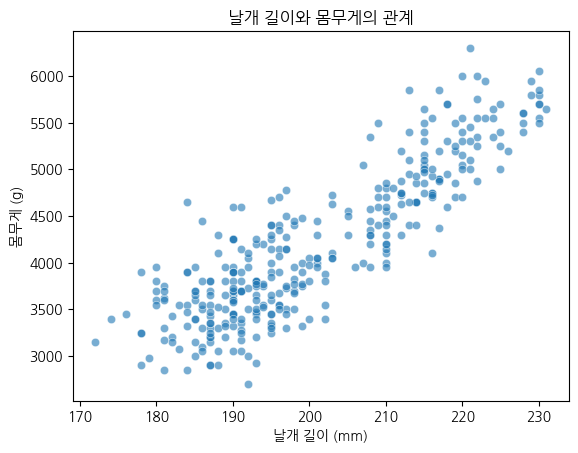

In [10]:
# 문제 2 · 데이터 준비 — 실행만 하세요
df_corr = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

print("결측치 제거 전:", len(penguins), "행")
print("결측치 제거 후:", len(df_corr), "행")

# 두 변수의 관계를 그림으로 먼저 확인 (문제 1의 교훈!)
sns.scatterplot(data=df_corr, x='flipper_length_mm', y='body_mass_g', alpha=0.6)
plt.title("날개 길이와 몸무게의 관계")
plt.xlabel("날개 길이 (mm)")
plt.ylabel("몸무게 (g)")
plt.show()

### Q1 · 피어슨의 전제인 정규성을 점검해 봅시다

- `flipper_length_mm`과 `body_mass_g` **각각**에 대해 정규성 검정(Shapiro-Wilk)을 수행하세요.

- 유의수준 0.05를 기준으로 '정규성을 기각하는지'까지 함께 출력하세요.

- `💡 힌트` `stats.shapiro(데이터)`는 통계량과 p-값을 함께 돌려줍니다.

In [ ]:
# 문제 2 · Q1
# 여기에 코드를 작성해주세요.
stat_flipper, p_flipper = stats.shapiro(df_corr['flipper_length_mm'])
stat_mass, p_mass = stats.shapiro(df_corr['body_mass_g'])

print(f"flipper_length_mm: 통계량={stat_flipper:.4f}, p-값={p_flipper:.4g}, "
        f"{'정규성 기각' if p_flipper < 0.05 else '정규성 기각 못함'}")
print(f"body_mass_g: 통계량={stat_mass:.4f}, p-값={p_mass:.4g}, "
        f"{'정규성 기각' if p_mass < 0.05 else '정규성 기각 못함'}")


flipper_length_mm: 통계량=0.9515, p-값=3.54e-09, 정규성 기각
body_mass_g: 통계량=0.9592, p-값=3.679e-08, 정규성 기각


### Q2 · 피어슨 상관계수와 p-값을 함께 구해 봅시다

- 상관계수만이 아니라 **p-값도 함께** 구하세요. 상관계수도 가설검정의 대상입니다.

- 결과는 반드시 `r`, `p_value`라는 이름으로 저장하세요. **문제 3·4에서 이어서 사용합니다.**

- `💡 힌트` `r, p_value = stats.pearsonr(x, y)` — 귀무가설은 "모집단의 상관계수가 0이다"입니다.

In [12]:
# 문제 2 · Q2
# 여기에 코드를 작성해주세요.
r, p_value = stats.pearsonr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])
print(f"피어슨 r = {r:.4f}, p-값 = {p_value:.4g}")


피어슨 r = 0.8712, p-값 = 4.371e-107


### Q3 · 스피어만 상관계수를 구해 피어슨과 비교해 봅시다

- 스피어만 상관계수(ρ)를 구하세요.

- Q2의 피어슨 값과 **나란히 출력**해 두 값의 차이를 눈으로 확인하세요.

- `💡 힌트` `stats.spearmanr(x, y)`

In [13]:
# 문제 2 · Q3
# 여기에 코드를 작성해주세요.
rho, p_rho = stats.spearmanr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])
print(f"피어슨 r = {r:.4f} (p={p_value:.4g})")
print(f"스피어만 ρ = {rho:.4f} (p={p_rho:.4g})")


피어슨 r = 0.8712 (p=4.371e-107)
스피어만 ρ = 0.8400 (p=2.763e-92)


### Q4 · 세 결과를 종합해 관계를 문장으로 정리해 봅시다

- Q1~Q3의 결과를 근거로, 오른쪽 빈칸을 채워 관계를 정리하세요.

- 숫자만 적지 말고 **그 숫자가 뜻하는 바**를 함께 쓰세요.

In [ ]:
# 문제 2 · Q4
# 정규성 검정 결과 (피어슨의 전제가 지켜졌나요?): 두 변수 모두 정규성 기각됨 -> 두 변수 모두 정규분포를 따른다고 보기 어렵다.
# 피어슨 r 값과 p-값: r = 0.87, p = 4.371e-107 < 0.05 -> 상관계수가 0이다. 라는 귀무가설 기각
# 스피어만 ρ 값: 0.8400 (p=2.763e-92)
# 부호(+/-)가 뜻하는 관계의 방향: +가 뜻하는 관계의 방향은 날개가 길수록 몸무게도 무거워지는 양의관계다.
# 절대값의 크기가 뜻하는 관계의 강도: 1에 가까운 매우 강한 상관관계이고, 날개 길이만으로도 몸무게를 잘 예측할 수 있는 수준이다.

### 💬 정리 · 결과를 말로 설명해 보기

- Q1에서 정규성이 기각되었습니다. 그렇다면 피어슨 상관계수를 쓰면 안 되는 걸까요? Q2와 Q3의 값을 비교해서 판단해 보세요.

- 피어슨과 스피어만이 비슷하게 나왔다는 것은 무엇을 뜻할까요? 만약 두 값이 크게 달랐다면 어떤 상황을 의심해야 할까요?

- Q2의 p-값은 무엇에 대한 검정인가요? "상관계수가 크다"와 "상관계수가 유의하다"는 같은 말인가요?

- '날개가 길어지는 것이 몸무게를 무겁게 만드는 **원인**이다'라고 결론 내릴 수 있을까요? **교란변수 / 역인과 / 우연** 세 가지로 나누어 설명해 보세요.

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 정규성이 깨졌을 때 확인할 것은 "쓰면 안 되나"가 아니라 **"결론이 바뀌는가"**입니다. 두 계수가 거의 같다면 전제 위배의 영향이 작다는 뜻이고, 크게 다르면 이상치나 비선형을 의심합니다.

- p-값은 관계의 **크기**가 아니라 **존재**에 대한 답입니다. 표본이 커지면 아주 작은 상관도 유의해집니다 — 두 질문을 분리해서 답해 보세요.

- 인과를 부정하는 세 갈래를 이 데이터에 대입해 보세요. 교란변수 후보는 문제 1에서 이미 만났습니다.

</details>

### 문제 2 · 정리
#### 여기에 의견을 작성해주세요.

- 쓰면 안되는 건 아니다. 피어슨 r값과 스피어만 ρ값이 거의 동일하므로, 정규성 위배가 결론에 큰 영향을 미치지는 않기 때문에 쓰면 안되는 건 아니다.
- 둘이 비슷하다는 건 두 변수의 관계가 대체적으로 선형관계이고, 극단적인 이상값이 적다는 뜻이다. 만약 두 값이 크게 달랐다면 이상치가 있거나 두 변수의 관계가 선형적이지 않은 상황을 의심해야한다.
- 모집단의 상관계수가 0이다. 라는 귀무가설에 대한 검정이다. 상관계수가 크다는 건 관계의 세기가 강하다.라는 뜻이고, 유의하다는 건 0이 아니라는 증거가 충분하다는 뜻이다. 
- 교란변수 : 종이 날개길이와 몸무게 둘 다에 영향을 주는 교란변수로 종을 통제하지 않으면 인과로 단정하기 어렵다. / 역인과 : 몸무게가 커서 날개가 길어졌다는 역인과도 완전히 배제하기는 어렵지만, 날개 길이가 몸집을 결정하는 쪽에 더 가깝다고 보는 게 일반적이다. / 우연 : 표본크기가 크고 r도 커서, 우연히 이런 관계가 나타났을 확률은 낮다.
- 결론적으로 상관은 강하지만, 종이라는 교란변수를 통제하지 않은 관찰 데이터이므로 날개가 길어지는 것이 몸무게를 무겁게 만드는 원인이라고 결론 내릴수는 없다. 

## 문제 3 · 그 관계를 하나의 식으로 만들 수 있을까?

`난이도 중` · `예상 25분`

**📖 상황**

- 상관계수는 "관계가 얼마나 **강한가**"만 알려주고, "날개가 1mm 길면 몸무게가 **몇 g** 늘어나는가"는
  말해주지 않습니다. 그 답을 주는 것이 **선형회귀(Linear Regression)**입니다.

- 흩어진 점들을 가장 잘 가로지르는 직선 `y = a + bx`를 찾아 관계를 하나의 **식**으로 표현합니다.
  `a`(절편)는 x가 0일 때의 예측값, `b`(기울기)는 **x가 1 늘 때 y가 평균적으로 변하는 양**입니다.

- 그런데 상관과 회귀는 **서로 남이 아닙니다.** 문제 2에서 구한 `r`과
  이번에 구할 기울기·결정계수 사이에는 정확한 관계식이 성립합니다.

**🎯 이 문제로 배우는 것**

- 회귀식을 적합·해석하고, **상관과 회귀가 한 뿌리임을 숫자로 확인**합니다.

In [14]:
# 문제 3 · 데이터 준비 — 실행만 하세요
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

print("분석에 사용할 데이터:", len(penguins_cleaned), "행")
print("문제 2의 df_corr과 동일한가?:", len(penguins_cleaned) == len(df_corr))

분석에 사용할 데이터: 342 행
문제 2의 df_corr과 동일한가?: True


### Q1 · 단순회귀 모델을 적합해 봅시다

- **날개 길이(설명변수) → 몸무게(반응변수)** 회귀 모델을 적합하세요.

- 적합한 모델은 반드시 `model`이라는 이름으로 저장하세요. **문제 4·5에서 이어서 사용합니다.**

- `💡 힌트` `model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=...).fit()`

In [15]:
# 문제 3 · Q1
# 여기에 코드를 작성해주세요.
model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=penguins_cleaned).fit()

### Q2 · 분석 결과표를 출력해 봅시다

- 적합한 모델의 요약 결과표를 출력하세요.

- `coef`, `P>|t|`, `R-squared` 열이 각각 어디에 있는지 눈으로 찾아 두세요. 다음 문제들에서 계속 씁니다.

- `💡 힌트` 모델 객체의 `.summary()` 메소드를 사용하세요.

In [17]:
# 문제 3 · Q2
# 여기에 코드를 작성해주세요.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        15:03:40   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

### Q3 · 회귀식을 완성해 봅시다

- Q2의 결과표에서 **절편**과 **기울기**를 찾아 오른쪽 빈칸을 채우세요.

- 숫자를 옮겨 적은 뒤, 완성된 식을 한 줄로 써 보세요.

In [ ]:
# 문제 3 · Q3
# 절편(a) 값: -5780.8314
# 기울기(b) 값: 49.6856
# 완성된 회귀식 → 몸무게(g) = -5780.8314 + 49.6856 × 날개길이(mm)

### Q4 · 회귀식으로 예측해 봅시다

- 날개 길이가 평균보다 **10mm 더 긴** 펭귄은, 평균적인 펭귄보다 몸무게가 몇 g 더 무거울까요?

- 계산 결과를 단위(g)와 함께 출력하세요.

- `💡 힌트` 기울기 × 10

In [18]:
# 문제 3 · Q4
# 여기에 코드를 작성해주세요.
slope = model.params['flipper_length_mm']
weight_diff = slope * 10
print(f"날개 길이가 10mm 더 길면 몸무게는 약 {weight_diff:.1f}g 더 무겁습니다.")

날개 길이가 10mm 더 길면 몸무게는 약 496.9g 더 무겁습니다.


### Q5 · 상관과 회귀를 잇는 두 관계식을 확인해 봅시다

- 다음 두 식이 실제로 성립하는지 **숫자로** 확인하세요.
  - ① 기울기 = `r` × (y의 표준편차 / x의 표준편차)
  - ② 결정계수 `R²` = `r²` _(단순회귀에서만 성립)_

- 좌변과 우변을 **나란히 출력**해 두 값이 일치하는지 눈으로 확인하세요.

- `💡 힌트` 문제 2 Q2의 `r`을 사용합니다. 표준편차는 `.std(ddof=1)`, 모델의 R²는 `model.rsquared`입니다.

In [19]:
# 문제 3 · Q5
# 여기에 코드를 작성해주세요.
y_std = penguins_cleaned['body_mass_g'].std(ddof=1)
x_std = penguins_cleaned['flipper_length_mm'].std(ddof=1)

slope_from_r = r * (y_std / x_std)
print(f"① 기울기(모델) = {slope:.4f}  vs  r × (Sy/Sx) = {slope_from_r:.4f}")

print(f"② R-squared(모델) = {model.rsquared:.4f}  vs  r² = {r**2:.4f}")


① 기울기(모델) = 49.6856  vs  r × (Sy/Sx) = 49.6856
② R-squared(모델) = 0.7590  vs  r² = 0.7590


### 💬 정리 · 결과를 말로 설명해 보기

- 기울기(b) 값을 "날개 길이가 ○○할 때 몸무게가 ○○한다"는 문장으로 풀어 써 보세요.

- 절편(a)이 음수로 나왔습니다. 이 숫자를 "날개 길이가 0mm인 펭귄의 몸무게"로 해석해도 될까요? 왜 그럴까요?

- Q5에서 `R² = r²`을 확인했습니다. 그렇다면 설명변수와 반응변수를 서로 바꿔 분석하면 **기울기**와 **R²**는 각각 같을까요, 다를까요?

- 상관계수 `r`은 단위 없는 −1~1 값이고, 기울기 `b`는 'mm당 g'이라는 단위를 가집니다. 회귀가 상관보다 더 알려주는 것은 무엇인가요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 절편은 **데이터가 존재하는 범위 밖의 값**입니다. 날개 길이 0mm인 펭귄은 우리 데이터에 없습니다 — 회귀식은 관측 범위 안에서만 의미를 갖습니다.

- x와 y를 바꿨을 때를 생각할 때 기준은 **"r은 대칭인가, s_y/s_x는 대칭인가"**입니다. 두 관계식 ①②를 각각 대입해 보면 답이 갈립니다.

- "강도"와 "변화량"의 차이로 정리해 보세요. 보고서에 "1mm당 ○g"을 쓸 수 있는 쪽은 어느 것인가요?

</details>

### 문제 3 · 정리
#### 여기에 의견을 작성해주세요.

- 날개 길이가 1mm 증가할 때 몸무게가 대략 50g 증가한다.
- 날개 길이가 0mm인 펭귄은 없기 때문에 안된다. 
- R²는 x,y를 바꿔도 값이 동일하기 때문에 같을것이고, 기울기는 x,y가 바뀌면 값도 달라지기 때문에 다를것이다.
- 회귀는 실제 단위를 가진 구체적인 변화량 즉 설명변수가 이만큼 증가할때 반응변수가 이만큼 증가한다. 라는 것을 알려준다.

## 문제 4 · 이 기울기, 우연이 아니라고 말할 수 있을까?

`난이도 중` · `예상 25분`

**📖 상황**

- 문제 3에서 기울기를 구했습니다. 그런데 이 값은 **표본 342마리에서 계산된 값**입니다.

- 만약 전체 펭귄 집단에서 두 변수가 실제로는 아무 관계가 없다면(**기울기 = 0**),
  우리가 얻은 기울기는 그저 **표본을 뽑는 과정에서 우연히 생긴 값**일 수도 있습니다.

- 이 의심에 답하는 것이 **회귀계수의 가설검정**이고, 결과표의 `P>|t|` 열이 판단 근거입니다.

**🎯 이 문제로 배우는 것**

- 강의에서 배운 **상관계수의 유의성 검정**과 회귀계수 검정이 **같은 검정**임을 확인하고,
  p-값이 항상 작게 나오는 것은 아니라는 사실을 **기각 실패 사례**로 직접 만납니다.

In [20]:
# 문제 4 · 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행 (문제 3과 동일)")
print("설명변수: flipper_length_mm  /  반응변수: body_mass_g")

분석 대상 데이터: 342 행 (문제 3과 동일)
설명변수: flipper_length_mm  /  반응변수: body_mass_g


### Q1 · 가설을 세워 봅시다

- 회귀계수(기울기)에 대한 귀무가설(H₀)과 대립가설(H₁)을 오른쪽 빈칸에 쓰세요.

- '기울기'가 무엇과 같은지/다른지를 명확히 적으세요.

In [ ]:
# 문제 4 · Q1
# H₀ (귀무가설): 
# H₁ (대립가설):

### Q2 · 기울기의 p-값을 찾아 봅시다

- `flipper_length_mm` 행에서 `P>|t|` 열의 값을 찾아 출력하세요.

- `💡 힌트` 결과표에서 눈으로 찾아도 되고, 모델 객체의 `.pvalues` 속성을 써도 됩니다.

In [ ]:
# 문제 4 · Q2
# 여기에 코드를 작성해주세요.

### Q3 · 유의수준 0.05로 결론을 내려 봅시다

- p-값과 유의수준 `alpha = 0.05`를 비교해, **판정 결과를 문장으로 출력하는 코드**를 작성하세요.

- 숫자만 찍지 말고 "기각한다 / 기각하지 못한다"까지 출력되도록 만드세요.

In [ ]:
# 문제 4 · Q3
# alpha = 0.05

# 여기에 코드를 작성해주세요.

### Q4 · 상관계수의 검정과 같은 검정인지 확인해 봅시다

- 강의에서 배운 공식으로 t-통계량을 **직접 계산**하세요.

  `t = r × √(n − 2) / √(1 − r²)`

- 이 값을 `model.tvalues['flipper_length_mm']`와 **나란히 출력**해 비교하세요.

- `💡 힌트` `n`은 표본 크기(`len(penguins_cleaned)`), `r`은 문제 2 Q2에서 구한 값입니다.

In [ ]:
# 문제 4 · Q4
# 여기에 코드를 작성해주세요.

### Q5 · p-값이 크게 나오는 사례를 만나 봅시다

- **Adelie 종 수컷만** 골라, `bill_length_mm`으로 `body_mass_g`를 설명하는 회귀를 적합하세요.

- 기울기의 p-값을 유의수준 0.05와 비교하고, 표본 크기(n)와 `R²`도 함께 출력하세요.

- `💡 힌트` 먼저 필요한 열의 결측치를 제거한 뒤 조건으로 걸러 냅니다.
  `df[(df['species'] == 'Adelie') & (df['sex'] == 'Male')]`

In [ ]:
# 문제 4 · Q5
# 여기에 코드를 작성해주세요.

### 💬 정리 · 결과를 말로 설명해 보기

- p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가요? "귀무가설이 참일 확률"이라고 말해도 될까요?

- Q4에서 두 t값이 일치했습니다. 이것은 상관계수의 검정과 회귀계수의 검정이 **어떤 관계**임을 뜻하나요?

- Q5의 결과는 Q2와 어떻게 달랐나요? 같은 `penguins` 데이터인데 결론이 갈린 이유를 **표본 크기**와 **관계의 강도(R²)** 두 측면에서 설명해 보세요.

- Q5처럼 p-값이 0.05보다 조금 큰 경우, "두 변수는 관계가 없음이 증명되었다"고 말할 수 있을까요? 어떻게 말하는 것이 정확할까요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- p-값은 "H₀가 참이라고 **가정했을 때** 이런 결과가 나올 확률"입니다. 가정과 결론의 방향을 뒤집지 않도록 문장을 조심해서 써 보세요.

- Q4의 일치는 우연이 아닙니다. 단순회귀에서는 "두 변수가 무관하다"는 하나의 가설을 두 가지 방식으로 적었을 뿐입니다 — 그래서 t도 p도 같습니다.

- 기각 실패는 **"관계가 없다"가 아니라 "관계가 있다는 증거가 부족하다"**입니다. Q5의 n과 R²를 보면 왜 증거가 부족했는지 짐작할 수 있습니다.

</details>

In [ ]:
# 문제 4 · 정리
# 여기에 의견을 작성해주세요.

## 문제 5 · 미니 프로젝트 — 이 회귀모형, 믿고 보고해도 될까?

`난이도 상` · `예상 35분`

**📖 상황**

- 계수가 유의하다고 해서 분석이 끝난 것은 아닙니다. 보고서를 쓰기 전에 두 가지를 더 확인합니다.

- **① 얼마나 설명하는가 — 결정계수(R²)**
  반응변수 전체 변동 중 이 모델이 설명한 비율입니다.

- **② 전제가 지켜졌는가 — 잔차(Residual) 진단**
  잔차는 `실제값 − 예측값`입니다. 좋은 모델이라면 잔차가 **패턴 없이 0 주위에 고르게** 흩어져야 합니다.
  깔때기(부채꼴) 모양이면 **등분산성**이 깨졌다는 신호이고, 이때는 p-값과 신뢰구간을 그대로 믿기 어렵습니다.

**🎯 이 문제로 배우는 것**

- 우리 모형을 진단한 뒤, **일부러 문제가 있는 다른 모형과 나란히 놓고 비교**합니다.
  "통과한 잔차"만 보면 진단을 왜 하는지 알 수 없기 때문입니다.

In [ ]:
# 문제 5 · 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행")
print("모형: body_mass_g ~ flipper_length_mm")

### Q1 · 결정계수로 설명력을 평가해 봅시다

- 모델의 `R-squared` 값을 출력하세요.

- 그 값이 뜻하는 바를 "몸무게 변동의 몇 %" 형태로 오른쪽 빈칸에 쓰세요.

- `💡 힌트` `model.rsquared`

In [ ]:
# 문제 5 · Q1
# R-squared 값:
# 설명력 해석 (몸무게 변동의 몇 %를 설명하나요?):

# 여기에 코드를 작성해주세요.

### Q2 · 예측값과 잔차를 계산해 봅시다

- 모델의 **예측값**과 **잔차**를 각각 계산해 변수에 저장하세요.

- 잔차의 개수와 평균을 함께 출력해, 잔차가 0 주위에 모여 있는지 확인하세요.

- `💡 힌트` 예측값은 `.fittedvalues`, 잔차는 `.resid` 속성입니다.

In [ ]:
# 문제 5 · Q2
# 여기에 코드를 작성해주세요.

### Q3 · 잔차 산점도를 그려 봅시다

- 가로축을 **예측값**, 세로축을 **잔차**로 하는 산점도를 그리세요.

- `y = 0` 기준선을 함께 표시하면 패턴을 보기 쉽습니다.

- `💡 힌트` `plt.scatter()` 와 `plt.axhline(0, color='red', linestyle='--')`

In [ ]:
# 문제 5 · Q3
# 여기에 코드를 작성해주세요.

### Q4 · 등분산성을 숫자로 검정해 봅시다

- **브루쉬-페이건 검정**으로 등분산성을 확인하세요.

- H₀는 "등분산이다"입니다. p-값이 0.05보다 작으면 이분산을 의심합니다.

- 판정 결과를 문장으로 함께 출력하세요.

- `💡 힌트` `het_breuschpagan(잔차, model.model.exog)`는
  `(LM통계량, LM p-값, F통계량, F p-값)`을 돌려줍니다.

In [ ]:
# 문제 5 · Q4
# 여기에 코드를 작성해주세요.

### Q5 · 문제가 있는 모형과 나란히 비교해 봅시다

- **비교군**으로 `body_mass_g ~ bill_length_mm` 모형을 적합해 `model_bill`로 저장하세요.

- 두 모형의 잔차 산점도를 **나란히** 그리세요.

- 두 모형의 브루쉬-페이건 p-값을 **함께 출력**해 비교하세요.

- `💡 힌트` `fig, ax = plt.subplots(1, 2, figsize=(12, 4))`로 두 그림을 옆으로 배치할 수 있습니다.

In [ ]:
# 문제 5 · Q5
# 여기에 코드를 작성해주세요.

### Q6 · 보고 문장으로 정리해 봅시다

- 지금까지의 결과를 종합해, 우리 회귀모형을 보고서에 어떻게 적을지 **한 문장**으로 쓰세요.

- **기울기 + 유의성 + 설명력 + 진단 결과**를 모두 담아 보세요.

In [ ]:
# 문제 5 · Q6
# 보고 문장:

### 💬 정리 · 결과를 말로 설명해 보기

- Q3·Q4에서 우리 모형의 잔차는 어떤 상태였나요? 이 결과를 근거로 문제 3·4의 해석을 신뢰할 수 있을까요?

- Q5의 두 잔차 산점도는 어떻게 달랐나요? 비교군에서 관찰된 모양을 강의에서 배운 용어로 무엇이라 부르나요?

- 비교군처럼 등분산성이 깨졌을 때, **잘못된 것은 기울기 값 자체인가요, 아니면 그 값의 통계적 해석인가요?**

- R²가 1이 아니라는 것은 설명되지 않은 변동이 남아 있다는 뜻입니다. `penguins` 안에서 몸무게에 영향을 줄 만한데 우리 모델이 놓치고 있는 변수는 무엇일까요?

- 그 변수들을 모델에 함께 넣으려면 어떤 분석이 필요할까요?

<details>
<summary>(클릭) 💡 생각의 갈피</summary>

- 강의 7장은 이렇게 적었습니다 — _"파라미터 값이 잘못되었다는 뜻이 아니라, 이 값의 통계적 해석(유의성·신뢰구간)과 예측 결과를 신뢰할 수 없다는 의미"_. 세 번째 질문의 답이 여기 있습니다.

- 비교군의 잔차가 퍼지는 모양을 강의의 3케이스 그림(정규성 O·등분산 O / X·O / O·X)과 맞춰 보세요.

- 놓친 변수 후보는 문제 1의 그림에 이미 있습니다. 그 변수를 모델에 함께 넣는 분석의 이름은 다음 8장의 제목입니다.

</details>

In [ ]:
# 문제 5 · 정리
# 여기에 의견을 작성해주세요.